In [1]:
import requests

station = "01048"  # Dresden-Klotzsche
url = f"https://dwd.api.proxy.bund.dev/v30/stationOverviewExtended?stationIDs={station}"

data = requests.get(url).json()
print(data)

{'title': 'Bad Request', 'status': 400, 'detail': "Required request parameter 'stationIds' for method parameter type List is not present"}


In [29]:
    # 1. PLZ in Koordinaten umwandeln
plz = '	01067'
geo_url = f"http://api.zippopotam.us/de/{plz}"
geo_res = requests.get(geo_url)
if geo_res.status_code != 200:
    print("Fehler: Postleitzahl nicht gefunden.")

location = geo_res.json()['places'][0]
lat, lon = location['latitude'], location['longitude']

print(f"Lade Daten für {location['place name']}", location['latitude'], location['longitude'])

Fehler: Postleitzahl nicht gefunden.


KeyError: 'places'

In [ ]:
'''

temp	Temperatur	°C	Lufttemperatur in 2 m Höhe
rhum	Relative Luftfeuchte	%	Verhältnis der aktuellen Feuchte zur maximal möglichen
prcp	Niederschlag	mm	Gesamtniederschlag der Stunde (Regen + Schnee)
snwd	Schneehöhe	cm	Gesamtschneehöhe am Boden
wdir	Windrichtung	°	0° = Nord, 90° = Ost, 180° = Süd, 270° = West
wspd	Windgeschwindigkeit	m/s	Durchschnittliche Windgeschwindigkeit
wpgt	Windböen	m/s	Maximale Windgeschwindigkeit in der Stunde
pres	Luftdruck	hPa	Stationsluftdruck (nicht auf Meereshöhe reduziert)
tsun	Sonnenscheindauer	min	Minuten direkter Sonneneinstrahlung in der Stunde
cldc	Cloud Cover	%	Anteil des Himmels, der von Wolken bedeckt ist
coco    Weather Condition Code
'''

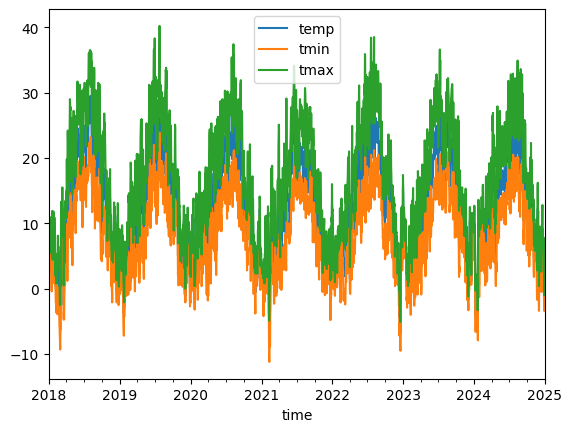

In [7]:
from datetime import date
import matplotlib.pyplot as plt
import meteostat as ms

# Specify location and time range
POINT = ms.Point(50.1155, 8.6842, 113)  # Try with your location
START = date(2018, 1, 1)
END = date(2025, 1, 1)

# Get nearby weather stations
stations = ms.stations.nearby(POINT, limit=4)

# Get daily data & perform interpolation
ts = ms.daily(stations, START, END)
df = ms.interpolate(ts, POINT).fetch()

# Plot line chart including average, minimum and maximum temperature
df.plot(y=[ms.Parameter.TEMP, ms.Parameter.TMIN, ms.Parameter.TMAX])
plt.show()

In [15]:
# Import Meteostat library and dependencies
from datetime import datetime
import meteostat as ms

# Set time period
start = datetime(2018, 1, 1)
end = datetime(2018, 12, 31, 23, 59)

# Get hourly data
ts = ms.hourly(ms.Station(id='10488'), start, end)
df = ts.fetch()

# Print DataFrame
print(df)

                     temp  rhum  prcp  snwd  wdir  wspd  wpgt    pres  tsun  \
time                                                                          
2018-01-01 00:00:00  10.8    67   0.0  <NA>   200  25.9  <NA>  1002.6  <NA>   
2018-01-01 01:00:00  11.1    64   0.0  <NA>   200  29.9  <NA>  1001.9  <NA>   
2018-01-01 02:00:00  11.5    61   0.0  <NA>   200  25.9  <NA>  1001.8  <NA>   
2018-01-01 03:00:00  11.2    61   0.0  <NA>   200  24.1  <NA>  1001.9     0   
2018-01-01 04:00:00  11.2    63   0.0  <NA>   220  21.2  <NA>  1002.2     0   
...                   ...   ...   ...   ...   ...   ...   ...     ...   ...   
2018-12-31 19:00:00   5.8    99   0.0  <NA>   260   9.7  18.0  1030.7     0   
2018-12-31 20:00:00   6.1    98   0.0  <NA>   250  11.9  18.0  1030.5     0   
2018-12-31 21:00:00   6.2   100   0.0  <NA>   250  11.5  22.0  1030.2     0   
2018-12-31 22:00:00   6.5   100   0.2  <NA>   260  12.2  21.0  1029.7     0   
2018-12-31 23:00:00   6.7   100   0.1  <NA>   260  1

In [14]:
import meteostat as ms

# Point(latitude, longitude, elevation)
#POINT = ms.Point(50.1155, 8.6842, 113)  # Frankfurtamain
POINT = ms.Point(51.0504, 13.7373, 113) # Dresden-Klotsche

# Get nearby weather stations
stations = ms.stations.nearby(POINT, limit=4)

print(stations)

                      name country region  latitude  longitude  elevation  \
id                                                                          
D1051     Dresden-Strehlen      DE     SN   51.0248    13.7750        120   
10486              Dresden      DE     SN   51.1167    13.6833        231   
D1050   Dresden-Hosterwitz      DE     SN   51.0221    13.8470        114   
10488  Dresden / Klotzsche      DE     SN   51.1333    13.7500        230   

            timezone  distance  
id                              
D1051  Europe/Berlin    3879.6  
10486  Europe/Berlin    8281.1  
D1050  Europe/Berlin    8290.9  
10488  Europe/Berlin    9260.6  


In [ ]:
# Postleitzahl zu Koordinaten
from geopy.geocoders import Nominatim

def geolocate(postleitzahl):
    geolocator = Nominatim(user_agent="plz_koordinaten")

    location = geolocator.geocode(postleitzahl) # als String!!!

    return (location.latitude, location.longitude)

print(geolocate("01067"))

(51.0601936, 13.7111692)


In [2]:
# solarstunden
import requests


def get_hourly_historical_solar(plz, year=2020):
    # 1. PLZ in Koordinaten umwandeln
    geo_url = f"http://api.zippopotam.us/de/{plz}"
    geo_res = requests.get(geo_url)
    if geo_res.status_code != 200:
        print("Fehler: Postleitzahl nicht gefunden.")
        return

    location = geo_res.json()['places'][0]
    lat, lon = location['latitude'], location['longitude']

    print(f"Lade Daten für {location['place name']} ({year})... Bitte warten.")

    # 2. PVGIS Hourly API abfragen (seriescalc)
    pvgis_url = "https://re.jrc.ec.europa.eu/api/v5_2/seriescalc"

    # KORRIGIERTE PARAMETER:
    params = {
        'lat': lat,
        'lon': lon,
        'startyear': year,
        'endyear': year,
        'outputformat': 'json',
        'angle': 35,  # Neigung des Solarmoduls (35 Grad ist in DE optimal)
        'aspect': 0,  # Ausrichtung (0 = exakt nach Süden)
        'pvcalculation': 0  # 0 = Wir wollen nur die Strahlung in W/m², nicht die fertige Anlagenleistung
    }

    response = requests.get(pvgis_url, params=params)

    if response.status_code != 200:
        print(f"\nFehler bei der Solar-API (Status Code {response.status_code})")
        print(f"Antwort der API: {response.text}")
        return

    data = response.json()
    hourly_records = data['outputs']['hourly']

    # 3. Ausgabe der ersten Stunden
    print(f"\n{'Zeitpunkt (UTC)':<20} | {'Strahlung (W/m²)':<15}")
    print("-" * 40)

    for record in hourly_records[:24]:  # Zeigt die ersten 24 Stunden des Jahres
        time = record['time']
        # G(i) ist jetzt garantiert vorhanden (Globalstrahlung auf geneigte Fläche)
        radiation = record['G(i)']
        print(f"{time:<20} | {radiation:>10} W/m²")

    # 4. Gesamtsumme berechnen
    total_energy_wh = sum(item['G(i)'] for item in hourly_records)
    total_energy_kwh = total_energy_wh / 1000

    print("-" * 40)
    print(f"Gesamtstrahlung im Jahr {year}: {round(total_energy_kwh, 2)} kWh/m²")


# Programm ausführen, nur bis 2020
get_hourly_historical_solar("09633", 2020)

Lade Daten für Halsbrücke (2020)... Bitte warten.

Zeitpunkt (UTC)      | Strahlung (W/m²)
----------------------------------------
20200101:0010        |        0.0 W/m²
20200101:0110        |        0.0 W/m²
20200101:0210        |        0.0 W/m²
20200101:0310        |        0.0 W/m²
20200101:0410        |        0.0 W/m²
20200101:0510        |        0.0 W/m²
20200101:0610        |        0.0 W/m²
20200101:0710        |        0.0 W/m²
20200101:0810        |     123.54 W/m²
20200101:0910        |     536.57 W/m²
20200101:1010        |     671.22 W/m²
20200101:1110        |     734.19 W/m²
20200101:1210        |     675.31 W/m²
20200101:1310        |     548.08 W/m²
20200101:1410        |     299.44 W/m²
20200101:1510        |        0.0 W/m²
20200101:1610        |        0.0 W/m²
20200101:1710        |        0.0 W/m²
20200101:1810        |        0.0 W/m²
20200101:1910        |        0.0 W/m²
20200101:2010        |        0.0 W/m²
20200101:2110        |        0.0 W/m²
20200101:2

In [3]:
import requests
import pandas as pd
from datetime import datetime

def get_solar_simulation(plz, year=2024, tilt=35, azimuth=0):
    # 1. PLZ in Koordinaten (Zippopotam)
    geo_url = f"http://api.zippopotam.us/de/{plz}"
    geo_res = requests.get(geo_url)
    if geo_res.status_code != 200:
        print("Fehler: PLZ nicht gefunden.")
        return
    
    loc = geo_res.json()['places'][0]
    lat, lon = loc['latitude'], loc['longitude']
    
    print(f"Simuliere {year} für {loc['place name']} (Neigung: {tilt}°, Süd={azimuth}°)...")

    # 2. Open-Meteo API (Historical / Forecast)
    # Nutzt 'estimated_pv_tilted' oder 'global_tilted_irradiance'
    url = "https://archive-api.open-meteo.com/v1/archive"
    
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": f"{year}-01-01",
        "end_date": f"{year}-12-31",
        "hourly": "global_tilted_irradiance",
        "tilt": tilt,
        "azimuth": azimuth,
        "timezone": "Europe/Berlin"
    }

    # Falls das Jahr in der Zukunft liegt oder heute ist, nutzen wir die Forecast API
    current_year = datetime.now().year
    if year >= current_year:
        url = "https://api.open-meteo.com/v1/forecast"
        # Forecast begrenzt auf max 16 Tage, für 2024/2025 ist 'archive' korrekt

    response = requests.get(url, params=params)
    
    if response.status_code != 200:
        print(f"Fehler: {response.json().get('reason', 'Unbekannt')}")
        return

    data = response.json()
    hourly = data['hourly']
    times = hourly['time']
    radiation = hourly['global_tilted_irradiance'] # W/m² auf die geneigte Fläche

    # 3. Auswertung (Pandas für einfache Summen)
    df = pd.DataFrame({'Zeit': times, 'Strahlung_W_m2': radiation})
    
    # Gesamtenergie berechnen (Wh -> kWh)
    total_kwh_m2 = df['Strahlung_W_m2'].sum() / 1000

    print("-" * 40)
    print(f"Ergebnis für {year}:")
    print(f"Erste 5 Stunden:\n{df.head()}")
    print("-" * 40)
    print(f"Gesamtstrahlung auf Modul: {round(total_kwh_m2, 2)} kWh/m² pro Jahr")

# Beispiel für das Jahr 2024 (bereits komplett verfügbar)
get_solar_simulation("09633", 2024, tilt=35, azimuth=0)

Simuliere 2024 für Halsbrücke (Neigung: 35°, Süd=0°)...
----------------------------------------
Ergebnis für 2024:
Erste 5 Stunden:
               Zeit  Strahlung_W_m2
0  2024-01-01T00:00             0.0
1  2024-01-01T01:00             0.0
2  2024-01-01T02:00             0.0
3  2024-01-01T03:00             0.0
4  2024-01-01T04:00             0.0
----------------------------------------
Gesamtstrahlung auf Modul: 1430.85 kWh/m² pro Jahr


In [4]:
import requests
import pandas as pd

def get_full_year_data(plz, year=2024, tilt=35, azimuth=0):
    # 1. Koordinaten holen
    geo_url = f"http://api.zippopotam.us/de/{plz}"
    geo_res = requests.get(geo_url)
    if geo_res.status_code != 200:
        return "PLZ nicht gefunden."
    
    loc = geo_res.json()['places'][0]
    lat, lon = loc['latitude'], loc['longitude']

    # 2. Alle Stunden des Jahres abrufen
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": f"{year}-01-01",
        "end_date": f"{year}-12-31",
        "hourly": "global_tilted_irradiance",
        "tilt": tilt,
        "azimuth": azimuth,
        "timezone": "Europe/Berlin"
    }

    response = requests.get(url, params=params)
    if response.status_code != 200:
        return f"API-Fehler: {response.status_code}"

    data = response.json()
    
    # 3. DataFrame erstellen
    df = pd.DataFrame({
        'Zeit': pd.to_datetime(data['hourly']['time']),
        'Strahlung': data['hourly']['global_tilted_irradiance']
    })

    # Wir setzen die Zeit als Index für direkten Zugriff
    df.set_index('Zeit', inplace=True)
    
    return df

# --- DATEN LADEN ---
# Das dauert einmalig ca. 1-2 Sekunden (8760 Zeilen)
df_2024 = get_full_year_data("09633", 2024)

# --- DATEN AUSLESEN ---
# Jetzt kannst du jederzeit beliebige Zeitpunkte abfragen:

# Beispiel 1: Exakter Zeitpunkt (dein Wunschformat)
zeitpunkt = pd.to_datetime("22-03-2024 14:00", dayfirst=True)
wert = df_2024.loc[zeitpunkt, 'Strahlung']
print(f"Strahlung am {zeitpunkt}: {wert} W/m²")

# Beispiel 2: Einen ganzen Tag auslesen (Slicing)
print("\nDaten für den Vormittag des 15. Juni:")
print(df_2024.loc['2024-06-15 08:00':'2024-06-15 12:00'])

# Beispiel 3: Den gesamten März filtern
maerz_daten = df_2024[df_2024.index.month == 3]

Strahlung am 2024-03-22 14:00:00: 260.9 W/m²

Daten für den Vormittag des 15. Juni:
                     Strahlung
Zeit                          
2024-06-15 08:00:00      283.1
2024-06-15 09:00:00       32.5
2024-06-15 10:00:00       81.6
2024-06-15 11:00:00      218.4
2024-06-15 12:00:00      425.5


In [1]:
import requests
import pandas as pd
import time

def get_multi_year_average(plz, start_year=2020, end_year=2024, tilt=35, azimuth=0):
    # 1. Koordinaten holen
    geo_url = f"http://api.zippopotam.us/de/{plz}"
    geo_res = requests.get(geo_url)
    if geo_res.status_code != 200:
        return "PLZ nicht gefunden."
    
    loc = geo_res.json()['places'][0]
    lat, lon = loc['latitude'], loc['longitude']
    
    all_data = []

    # 2. Daten für jedes Jahr abrufen
    for year in range(start_year, end_year + 1):
        print(f"Lade Daten für {year}...")
        url = "https://archive-api.open-meteo.com/v1/archive"
        params = {
            "latitude": lat, "longitude": lon,
            "start_date": f"{year}-01-01", "end_date": f"{year}-12-31",
            "hourly": "global_tilted_irradiance",
            "tilt": tilt, "azimuth": azimuth, "timezone": "Europe/Berlin"
        }
        
        res = requests.get(url, params=params)
        if res.status_code == 200:
            data = res.json()
            temp_df = pd.DataFrame({
                'Zeit': pd.to_datetime(data['hourly']['time']),
                'Strahlung': data['hourly']['global_tilted_irradiance']
            })
            all_data.append(temp_df)
        
        time.sleep(1) # Kurze Pause für die API-Limits

    # 3. Alle Jahre zusammenführen
    full_df = pd.concat(all_data)

    # 4. Bereinigung: 29. Februar entfernen
    full_df = full_df[~((full_df['Zeit'].dt.month == 2) & (full_df['Zeit'].dt.day == 29))]

    # 5. Durchschnitt berechnen (Gruppieren nach Monat, Tag und Stunde)
    # Wir erstellen Hilfsspalten für die Gruppierung
    full_df['Monat_Tag_Stunde'] = full_df['Zeit'].dt.strftime('%d-%m %H:00')
    
    # Mittelwert über alle Jahre für jede dieser Zeitpunkte
    avg_df = full_df.groupby('Monat_Tag_Stunde')['Strahlung'].mean().reset_index()

    # 6. Speichern als CSV
    filename = f"solar_average_{plz}.csv"
    avg_df.to_csv(filename, index=False)
    print(f"--- Durchschnittsberechnung fertig! Gespeichert als {filename} ---")
    
    return avg_df

# --- PROGRAMM STARTEN ---
# Wir berechnen den Durchschnitt von 2020 bis Ende 2024
df_avg = get_multi_year_average("09633")

# --- ABFRAGE-FUNKTION ---
def hole_wert(df, zeit_string):
    """ Erwartet Format 'TT-MM SS:00', z.B. '22-03 14:00' """
    result = df[df['Monat_Tag_Stunde'] == zeit_string]
    if not result.empty:
        return result.iloc[0]['Strahlung']
    return "Keine Daten gefunden."

# Test-Abfrage
wunsch_zeit = "22-03 14:00"
print(f"Durchschnittliche Strahlung am {wunsch_zeit}: {hole_wert(df_avg, wunsch_zeit):.2f} W/m²")

Lade Daten für 2020...
Lade Daten für 2021...
Lade Daten für 2022...
Lade Daten für 2023...
Lade Daten für 2024...
--- Durchschnittsberechnung fertig! Gespeichert als solar_average_09633.csv ---
Durchschnittliche Strahlung am 22-03 14:00: 535.62 W/m²


In [3]:
for i in range(6):
    wunsch_zeit = f"24-03 1{i}:00"
    print(f"Durchschnittliche Strahlung am {wunsch_zeit}: {hole_wert(df_avg, wunsch_zeit):.2f} W/m²")

Durchschnittliche Strahlung am 24-03 10:00: 486.90 W/m²
Durchschnittliche Strahlung am 24-03 11:00: 598.70 W/m²
Durchschnittliche Strahlung am 24-03 12:00: 674.98 W/m²
Durchschnittliche Strahlung am 24-03 13:00: 674.64 W/m²
Durchschnittliche Strahlung am 24-03 14:00: 686.52 W/m²
Durchschnittliche Strahlung am 24-03 15:00: 530.10 W/m²


In [ ]:
# CVS solar_base abhängig nur vom Wetter

import requests
import pandas as pd
import time

# --- TEIL 1: WETTERDATEN (ROHDATEN) HOLEN ---
def generate_solar_base_data(plz, start_year=2019, end_year=2023):
    # 1. Koordinaten sicher abrufen
    geo_url = f"http://api.zippopotam.us/de/{plz}"
    lat, lon = 51.05, 13.74 # Standard-Fallback: Dresden
    
    try:
        geo_res = requests.get(geo_url)
        if geo_res.status_code == 200:
            loc = geo_res.json()['places'][0]
            lat = float(loc['latitude'])
            lon = float(loc['longitude'])
            # Wichtig: Manche APIs geben Längengrad extrem hoch aus (z.B. PLZ-Fragmente)
            # Wir stellen sicher, dass Lat/Lon im Bereich von Deutschland liegen
            if not (47 < lat < 55): lat = 51.05 
        print(f"Nutze Koordinaten für {plz}: Breite={lat}, Länge={lon}")
    except Exception as e:
        print(f"PLZ-Fehler, nutze Dresden Default. ({e})")

    all_years = []

    # 2. Historische Wetterdaten von Open-Meteo laden
    for year in range(start_year, end_year + 1):
        print(f"Lade Jahr {year}...")
        url = "https://archive-api.open-meteo.com/v1/archive"
        params = {
            "latitude": lat,
            "longitude": lon,
            "start_date": f"{year}-01-01",
            "end_date": f"{year}-12-31",
            "hourly": "shortwave_radiation,diffuse_radiation,direct_normal_irradiance",
            "timezone": "auto"
        }
        
        try:
            res = requests.get(url, params=params)
            data = res.json()
            
            if 'hourly' in data:
                h = data['hourly']
                df = pd.DataFrame({
                    'time': pd.to_datetime(h.get('time')),
                    'ghi': h.get('shortwave_radiation'),
                    'dhi': h.get('diffuse_radiation'),
                    'dni': h.get('direct_normal_irradiance')
                })
                # 29. Februar entfernen
                df = df[~((df['time'].dt.month == 2) & (df['time'].dt.day == 29))]
                all_years.append(df)
                print(f"  -> {year} erfolgreich geladen.")
            else:
                print(f"  -> Fehler in API-Antwort für {year}: {data.get('reason')}")
        except Exception as e:
            print(f"  -> Netzwerkfehler im Jahr {year}: {e}")
        
        time.sleep(1.5)

    if not all_years:
        return None, lat, lon

    # 3. Durchschnittsberechnung (Das "Standard-Wetterjahr")
    full_df = pd.concat(all_years)
    full_df['mm_dd_hh'] = full_df['time'].dt.strftime('%m-%d %H:00')
    avg_df = full_df.groupby('mm_dd_hh').mean(numeric_only=True).reset_index()
    avg_df = avg_df.sort_values('mm_dd_hh')
    
    filename = f"solar_base_{plz}.csv"
    avg_df.to_csv(filename, index=False)
    print(f"\nBasisdaten gespeichert: {filename}")
    return avg_df, lat, lon

# --- HAUPTPROGRAMM ---
plz_eingabe = "01067"
base_data, latitude, longitude = generate_solar_base_data(plz_eingabe)


Nutze Koordinaten für 01067: Breite=51.05, Länge=51.05
Lade Jahr 2019...
  -> 2019 erfolgreich geladen.
Lade Jahr 2020...
  -> 2020 erfolgreich geladen.
Lade Jahr 2021...
  -> 2021 erfolgreich geladen.
Lade Jahr 2022...
  -> 2022 erfolgreich geladen.
Lade Jahr 2023...
  -> 2023 erfolgreich geladen.

Basisdaten gespeichert: solar_base_01067.csv


ValueError: Cannot infer dst time from 2023-10-29 02:00:00 as there are no repeated times

In [22]:
import pandas as pd
import pvlib
import numpy as np

def calculate_tilted_irradiance(csv_path, tilt, azimuth, lat, lon):
    # 1. CSV Laden
    df = pd.read_csv(csv_path)
    
    # Sicherstellen, dass die Spalten passen (wir nehmen die letzten 3 als ghi, dhi, dni)
    if 'mm_dd_hh' not in df.columns:
        df.columns = ['mm_dd_hh', 'ghi', 'dhi', 'dni']
    
    # 2. Daten bereinigen & Gruppieren (8760 Zeilen)
    df_clean = df.groupby('mm_dd_hh').mean(numeric_only=True).reset_index()
    df_clean = df_clean.sort_values('mm_dd_hh')

    # 3. Zeitstempel für die Geometrie (UTC)
    times = pd.to_datetime("2023-" + df_clean['mm_dd_hh'], format="%Y-%m-%d %H:%M")
    times_utc = times.dt.tz_localize('UTC')

    # 4. Sonnenstand berechnen
    solpos = pvlib.solarposition.get_solarposition(times_utc, lat, lon)
    
    # Längen-Check
    if len(solpos) != len(df_clean):
        solpos = solpos.iloc[:len(df_clean)]

    # 5. Einstrahlung berechnen
    # Wir übergeben Numpy-Arrays
    total_irrad = pvlib.irradiance.get_total_irradiance(
        surface_tilt=tilt,
        surface_azimuth=azimuth,
        dni=df_clean['dni'].to_numpy(),
        ghi=df_clean['ghi'].to_numpy(),
        dhi=df_clean['dhi'].to_numpy(),
        solar_zenith=solpos['zenith'].to_numpy(),
        solar_azimuth=solpos['azimuth'].to_numpy()
    )
    
    # HIER WAR DER FEHLER: total_irrad['poa_global'] ist bereits ein Numpy-Array!
    # Kein .values dahinter setzen.
    df_clean['leistung_geneigt'] = total_irrad['poa_global']
    
    return df_clean

def hole_leistung(df, monat, tag, stunde):
    # Erstellt den passenden Such-String, z.B. "03-02 12:00"
    such_string = f"{monat:02d}-{tag:02d} {stunde:02d}:00"
    
    ergebnis = df[df['mm_dd_hh'] == such_string]
    
    if not ergebnis.empty:
        return ergebnis['leistung_geneigt'].iloc[0]
    return 0.0 # Falls Nacht oder ungültiges Datum

def hole_leistung_kw(df, monat, tag, stunde, kwp_anlage):
    # Such-String wie gehabt
    such_string = f"{monat:02d}-{tag:02d} {stunde:02d}:00"
    
    ergebnis = df[df['mm_dd_hh'] == such_string]
    
    if not ergebnis.empty:
        strahlung = ergebnis['leistung_geneigt'].iloc[0]
        # Umrechnung: Strahlung / 1000 * kWp
        leistung_kw = (strahlung / 1000) * kwp_anlage
        return leistung_kw
    return 0.0

# --- ANWENDUNG ---
PLZ = "01067"
DATEI = f"solar_base_{PLZ}.csv"
BREITE, LAENGE = 51.05, 13.74
NEIGUNG, AUSRICHTUNG = 35, 180 

try:
    ergebnis_df = calculate_tilted_irradiance(DATEI, NEIGUNG, AUSRICHTUNG, BREITE, LAENGE)

    print("\n--- BERECHNUNG ERFOLGREICH ---")
    print(f"Datensätze: {len(ergebnis_df)}")
    print(f"Jahresertrag: {(ergebnis_df['leistung_geneigt'].sum()/1000):.2f} kWh/m²")
    
    # Test-Check (Hier nutzen wir .iloc[0], das ist sicherer)
    beispiel = ergebnis_df[ergebnis_df['mm_dd_hh'] == '06-15 12:00']
    if not beispiel.empty:
        print(f"Mittagswert im Juni: {beispiel['leistung_geneigt'].iloc[0]:.2f} W/m²")

    # Beispielaufruf:
    p = hole_leistung(ergebnis_df, 3, 2, 12)
    print(f"Leistung am 02.03 12:00: {p:.2f} W/m²")

    # --- BEISPIEL ANWENDUNG ---
    meine_kwp = 10.0  # Angenommen, du planst eine 10 kWp Anlage

    p_kw = hole_leistung_kw(ergebnis_df, 3, 2, 12, meine_kwp)

    print(f"\n--- ERGEBNIS FÜR {meine_kwp} kWp ANLAGE ---")
    print(f"Leistung am 02.03. um 12:00: {p_kw:.2f} kW")

    # Auch der Jahresertrag lässt sich so leicht berechnen:
    jahres_ertrag_kwh = (ergebnis_df['leistung_geneigt'].sum() / 1000) * meine_kwp
    print(f"Voraussichtlicher Jahresertrag: {jahres_ertrag_kwh:.2f} kWh")

except Exception as e:
    print(f"Fehler: {e}")
    # Zur Fehlersuche:
    import traceback
    traceback.print_exc()


--- BERECHNUNG ERFOLGREICH ---
Datensätze: 8760
Jahresertrag: 1364.33 kWh/m²
Mittagswert im Juni: 704.45 W/m²
Leistung am 02.03 12:00: 546.78 W/m²

--- ERGEBNIS FÜR 10.0 kWp ANLAGE ---
Leistung am 02.03. um 12:00: 5.47 kW
Voraussichtlicher Jahresertrag: 13643.32 kWh


In [23]:
import requests
import pandas as pd
import time
import os

# --- TEIL 1: WETTERDATEN HOLEN & STATISTIK ERSTELLEN ---
def generate_weather_master(plz, start_year=2019, end_year=2024):
    # 1. Ordner erstellen
    output_dir = "solar_base"
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        print(f"Ordner '{output_dir}' erstellt.")

    # 2. Koordinaten abrufen
    geo_url = f"http://api.zippopotam.us/de/{plz}"
    lat, lon = 51.05, 13.74 # Fallback Dresden
    
    try:
        geo_res = requests.get(geo_url)
        if geo_res.status_code == 200:
            loc = geo_res.json()['places'][0]
            lat, lon = float(loc['latitude']), float(loc['longitude'])
            if not (47 < lat < 55): lat, lon = 51.05, 13.74
        print(f"Koordinaten für {plz}: {lat}, {lon}")
    except:
        print("Nutze Fallback-Koordinaten.")

    all_data_frames = []

    # 3. Historische Daten laden
    for year in range(start_year, end_year + 1):
        print(f"Lade Wetterdaten für {year}...")
        url = "https://archive-api.open-meteo.com/v1/archive"
        params = {
            "latitude": lat,
            "longitude": lon,
            "start_date": f"{year}-01-01",
            "end_date": f"{year}-12-31",
            "hourly": "shortwave_radiation,diffuse_radiation,direct_normal_irradiance",
            "timezone": "UTC" # UTC verhindert DST-Probleme (Sommerzeit)
        }
        
        try:
            res = requests.get(url, params=params)
            data = res.json()
            if 'hourly' in data:
                h = data['hourly']
                df = pd.DataFrame({
                    'time': pd.to_datetime(h.get('time')),
                    'ghi': h.get('shortwave_radiation'),
                    'dhi': h.get('diffuse_radiation'),
                    'dni': h.get('direct_normal_irradiance')
                })
                # Schalttage entfernen für einheitliche 8760 Stunden
                df = df[~((df['time'].dt.month == 2) & (df['time'].dt.day == 29))]
                all_data_frames.append(df)
            else:
                print(f" Keine Daten für {year}")
        except Exception as e:
            print(f" Fehler im Jahr {year}: {e}")
        
        time.sleep(1.0) # API-Schonung

    if not all_data_frames:
        print("Keine Daten gefunden!")
        return

    # 4. Statistiken berechnen (Flattening)
    full_df = pd.concat(all_data_frames)
    full_df['mm_dd_hh'] = full_df['time'].dt.strftime('%m-%d %H:00')

    # Gruppierung: Wir holen Mean, Min und Max für alle drei Strahlungsarten
    master_df = full_df.groupby('mm_dd_hh').agg({
        'ghi': ['mean', 'min', 'max'],
        'dhi': ['mean', 'min', 'max'],
        'dni': ['mean', 'min', 'max']
    })

    # Header flach machen: mm_dd_hh, ghi_mean, ghi_min, ghi_max, ...
    master_df.columns = [f"{col[0]}_{col[1]}" for col in master_df.columns.values]
    master_df = master_df.reset_index().sort_values('mm_dd_hh')

    # 5. Speichern
    filename = os.path.join(output_dir, f"weather_master_{plz}.csv")
    master_df.to_csv(filename, index=False)
    
    print("-" * 30)
    print(f"FERTIG! Datei gespeichert: {filename}")
    print(f"Spalten: {', '.join(master_df.columns.tolist())}")
    return master_df

# --- START ---
plz_eingabe = "01067"
weather_data = generate_weather_master(plz_eingabe)

Ordner 'solar_base' erstellt.
Koordinaten für 01067: 51.05, 13.74
Lade Wetterdaten für 2019...
Lade Wetterdaten für 2020...
Lade Wetterdaten für 2021...
Lade Wetterdaten für 2022...
Lade Wetterdaten für 2023...
Lade Wetterdaten für 2024...
------------------------------
FERTIG! Datei gespeichert: solar_base\weather_master_01067.csv
Spalten: mm_dd_hh, ghi_mean, ghi_min, ghi_max, dhi_mean, dhi_min, dhi_max, dni_mean, dni_min, dni_max


In [26]:
import pandas as pd
import pvlib
import numpy as np
import os

def calculate_tilted_irradiance(csv_path, tilt, azimuth, lat, lon, scenario='mean'):
    """
    Berechnet die Einstrahlung auf einer geneigten Fläche.
    scenario: 'mean', 'min' oder 'max' (entspricht den Suffixen in der Master-CSV)
    """
    # 1. Master-CSV Laden
    df = pd.read_csv(csv_path)
    df = df.sort_values('mm_dd_hh')
    
    # 2. Zeitstempel für die Geometrie (UTC)
    # Wir nehmen ein fiktives Jahr 2023 für die Sonnenstandsberechnung
    times = pd.to_datetime("2023-" + df['mm_dd_hh'], format="%Y-%m-%d %H:%M")
    times_utc = times.dt.tz_localize('UTC')

    # 3. Sonnenstand berechnen
    solpos = pvlib.solarposition.get_solarposition(times_utc, lat, lon)
    
    # Längen-Check (Sicherheitsnetz)
    if len(solpos) != len(df):
        solpos = solpos.iloc[:len(df)]

    # 4. Spalten dynamisch wählen (z.B. ghi_mean, ghi_min, etc.)
    # WICHTIG: Nutze hier genau die Suffixe, die dein Master-Skript erstellt hat
    dni_data = df[f'dni_{scenario}'].to_numpy()
    ghi_data = df[f'ghi_{scenario}'].to_numpy()
    dhi_data = df[f'dhi_{scenario}'].to_numpy()

    # 5. Einstrahlung berechnen
    total_irrad = pvlib.irradiance.get_total_irradiance(
        surface_tilt=tilt,
        surface_azimuth=azimuth,
        dni=dni_data,
        ghi=ghi_data,
        dhi=dhi_data,
        solar_zenith=solpos['zenith'].to_numpy(),
        solar_azimuth=solpos['azimuth'].to_numpy()
    )
    
    # Das Ergebnis in einer neuen Spalte speichern
    df['leistung_geneigt'] = total_irrad['poa_global']
    
    return df

# --- HILFSFUNKTIONEN (unverändert, nutzen die 'leistung_geneigt' Spalte) ---
def hole_leistung(df, monat, tag, stunde):
    such_string = f"{monat:02d}-{tag:02d} {stunde:02d}:00"
    ergebnis = df[df['mm_dd_hh'] == such_string]
    if not ergebnis.empty:
        return ergebnis['leistung_geneigt'].iloc[0]
    return 0.0

def hole_leistung_kw(df, monat, tag, stunde, kwp_anlage):
    such_string = f"{monat:02d}-{tag:02d} {stunde:02d}:00"
    ergebnis = df[df['mm_dd_hh'] == such_string]
    if not ergebnis.empty:
        strahlung = ergebnis['leistung_geneigt'].iloc[0]
        return (strahlung / 1000) * kwp_anlage
    return 0.0

# --- ANWENDUNG ---
PLZ = "01067"
# Pfad zur Master-Wetterdatei im solar_base Ordner
DATEI = os.path.join("solar_base", f"weather_master_{PLZ}.csv")

BREITE, LAENGE = 51.05, 13.74
NEIGUNG, AUSRICHTUNG = 35, 180 
MEINE_KWP = 10.0

# HIER WÄHLST DU DAS SZENARIO: 'mean', 'min' oder 'max'
WAHL = 'max' 

try:
    # Berechnung mit dem gewählten Szenario
    ergebnis_df = calculate_tilted_irradiance(DATEI, NEIGUNG, AUSRICHTUNG, BREITE, LAENGE, scenario=WAHL)

    print(f"\n--- BERECHNUNG FÜR SZENARIO: {WAHL.upper()} ---")
    print(f"Jahresertrag ({MEINE_KWP} kWp): {(ergebnis_df['leistung_geneigt'].sum() / 1000 * MEINE_KWP):,.2f} kWh")

    # Beispielabfrage 02.03. 12:00
    p_kw = hole_leistung_kw(ergebnis_df, 3, 2, 12, MEINE_KWP)
    print(f"Leistung am 02.03. 12:00: {p_kw:.2f} kW")

except Exception as e:
    print(f"Fehler: {e}")
    import traceback
    traceback.print_exc()


--- BERECHNUNG FÜR SZENARIO: MAX ---
Jahresertrag (10.0 kWp): 23,904.58 kWh
Leistung am 02.03. 12:00: 10.00 kW


In [ ]:
# strompreis

import requests
from datetime import datetime


def get_spot_prices(start_date, end_date):
    # bzn=DE-LU ist die deutsche Preiszone (gültig seit Okt 2018)
    url = "https://api.energy-charts.info/price"
    params = {
        "bzn": "DE-LU",
        "start": start_date,  # Format: YYYY-MM-DD
        "end": end_date
    }

    print(f"Lade stündliche Spotmarktpreise von {start_date} bis {end_date}...")
    response = requests.get(url, params=params)

    if response.status_code != 200:
        print(f"Fehler bei der Abfrage: {response.status_code}")
        print(response.text)
        return

    data = response.json()

    # Die API liefert zwei lange Listen: Zeitstempel (unix_seconds) und Preise (price)
    unix_seconds = data['unix_seconds']
    prices = data['price']

    print(f"\n{'Datum & Uhrzeit':<20} | {'Preis (EUR/MWh)':<15} | {'Preis (Cent/kWh)':<15}")
    print("-" * 55)

    # Zur Demonstration geben wir nur die ersten 24 Stunden aus
    for i in range(min(24, len(prices))):
        # UNIX-Zeitstempel in ein lesbares Datum umwandeln
        dt = datetime.fromtimestamp(unix_seconds[i])
        time_str = dt.strftime('%Y-%m-%d %H:00')

        # Preis auslesen (kann manchmal 'None' sein, wenn Daten fehlen)
        price_eur_mwh = prices[i]

        if price_eur_mwh is not None:
            # Umrechnung: 1 EUR/MWh = 0.1 Cent/kWh (Einfach durch 10 teilen)
            price_cent_kwh = price_eur_mwh / 10
            print(f"{time_str:<20} | {price_eur_mwh:>13.2f} | {price_cent_kwh:>13.2f}")
        else:
            print(f"{time_str:<20} | {'Keine Daten':>13} | {'Keine Daten':>13}")

    # Kleiner Bonus: Durchschnittspreis des Jahres berechnen
    valid_prices = [p for p in prices if p is not None]
    if valid_prices:
        avg_price = sum(valid_prices) / len(valid_prices)
        print("-" * 55)
        print(f"Durchschnittspreis im Zeitraum: {round(avg_price / 10, 2)} Cent/kWh")


# Führe das Skript für das gesamte Jahr 2023 aus
get_spot_prices("2023-01-01", "2023-12-31")